# Sign Language Recognition Model Training

### Data Extraction

In [10]:
import os
import csv
import cv2
import mediapipe as mp




mp_hands = mp.solutions.hands
hands = mp_hands.Hands(
    static_image_mode = True,
    max_num_hands = 1,
    min_detection_confidence=0.5
    )
mp_draw = mp.solutions.drawing_utils

train_images_dir = "../DataSet/archive/asl_alphabet_train/asl_alphabet_train"

with open(file = "extracted_data.csv", mode = "w", newline= '') as file:
    writer = csv.writer(file)

    dirs_list = os.listdir(train_images_dir)

    for dirs in dirs_list:
        if dirs.startswith("."):
            continue

        dir_name = dirs
        print("letter ", dirs, " is being extracted")
        #print("Plik: ", image, "uciety na: ", image_name_split)

        full_dir = os.path.join(train_images_dir, dir_name)
        dir_images = os.listdir(full_dir)

        for image in dir_images:
            if image.startswith("."):
                continue

            image_dir = os.path.join(full_dir, image)

            image_from_dir = cv2.imread(image_dir)
            image_rgb = cv2.cvtColor(image_from_dir, cv2.COLOR_BGR2RGB)
            #cv2.imshow("Sign Language", image_rgb)

            #wrzucamh do silnika mediapipe
            mp_result = hands.process(image_rgb)

            if mp_result.multi_hand_landmarks:
                row = []
                for result in mp_result.multi_hand_landmarks:
                    for point in result.landmark:
                        x_coordinate = point.x
                        y_coordinate = point.y
                        z_coordinate = point.z

                        row.append(x_coordinate)
                        row.append(y_coordinate)
                        row.append(z_coordinate)


                row.append(dir_name)
                writer.writerow(row)

            else:
                continue

    print("dane zapisane do .csv")

letter  R  is being extracted
letter  U  is being extracted
letter  I  is being extracted
letter  N  is being extracted
letter  G  is being extracted
letter  Z  is being extracted
letter  T  is being extracted
letter  S  is being extracted
letter  A  is being extracted
letter  F  is being extracted
letter  O  is being extracted
letter  H  is being extracted
letter  del  is being extracted
letter  nothing  is being extracted
letter  space  is being extracted
letter  M  is being extracted
letter  J  is being extracted
letter  C  is being extracted
letter  D  is being extracted
letter  V  is being extracted
letter  Q  is being extracted
letter  X  is being extracted
letter  E  is being extracted
letter  B  is being extracted
letter  K  is being extracted
letter  L  is being extracted
letter  Y  is being extracted
letter  P  is being extracted
letter  W  is being extracted
dane zapisane do .csv


## Model Trainging

Loading data from .csv


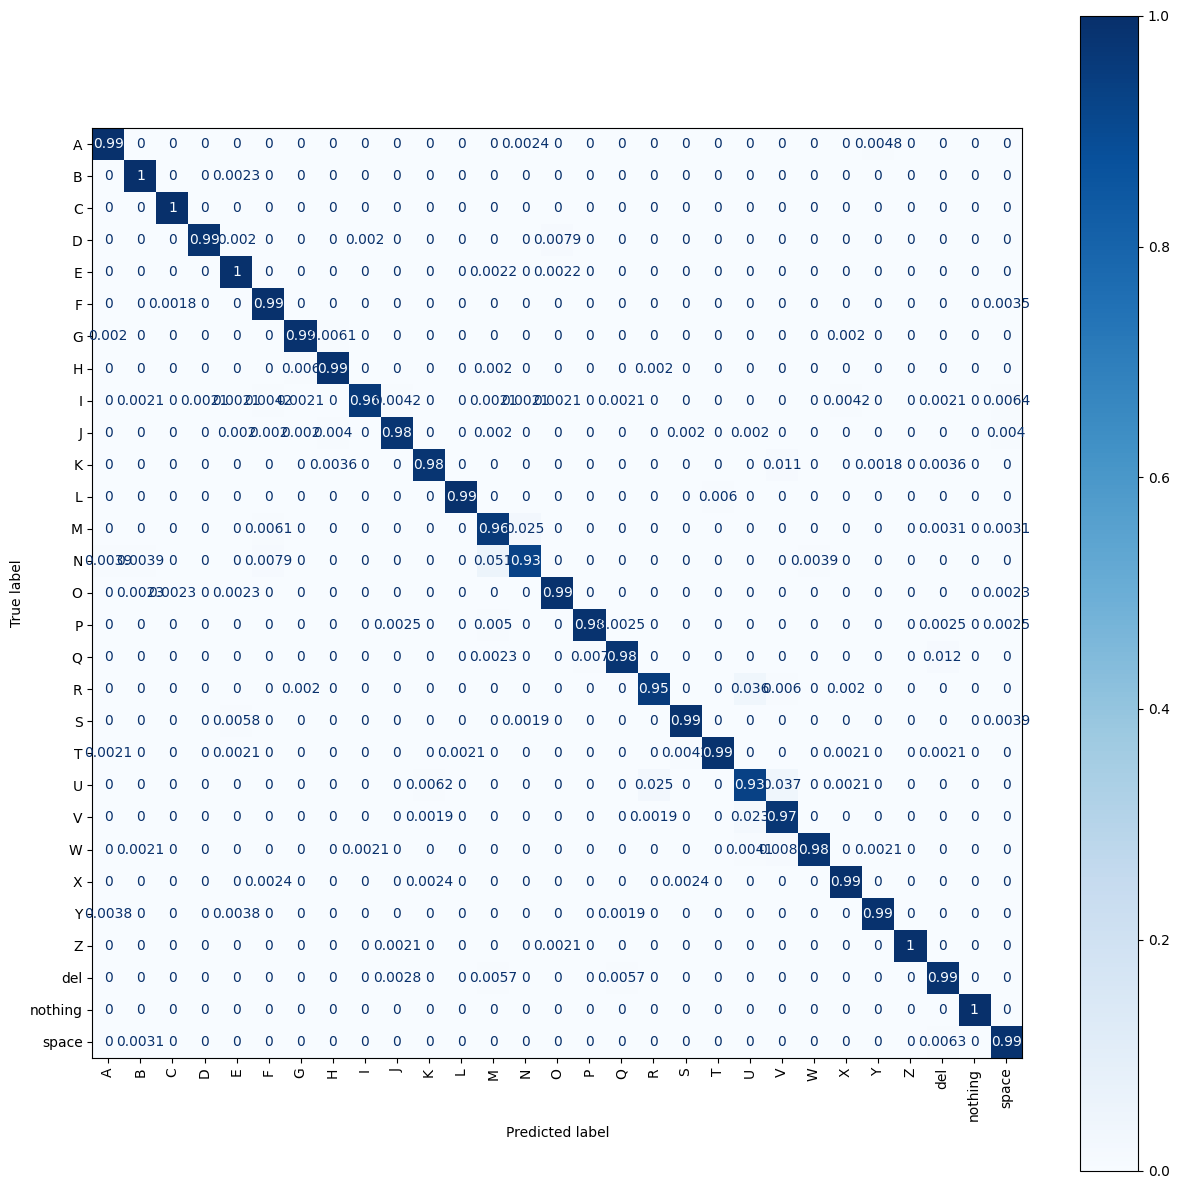

Model accuracy: 98.21751079701609%


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pickle

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


print("Loading data from .csv")

asl_table = pd.read_csv("extracted_data.csv", header=None)

X = asl_table.iloc[:,:-1]

y = asl_table.iloc[:,-1]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


model = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)

model.fit(X_train, y_train)

model_predict = model.predict(X_test)

score = accuracy_score(y_test, model_predict)


# macierz pomyłek
# model.classes_ do sortowania alfabetycznie
cm = confusion_matrix(y_test, model_predict, labels=model.classes_, normalize='true')

fig, ax = plt.subplots(figsize=(15, 15))

display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

# Mapa cieplna
display.plot(ax=ax, cmap='Blues', xticks_rotation='vertical')
plt.show()



print(f"Model accuracy: {score * 100:.2f}%")

with open("asl_model.pkl", "wb") as save_file:
    pickle.dump(model, save_file)





# Evaluation